# BTP Mid-Evaluation — Live Demonstration
## Fronthaul Load Management in 5G C-RAN / O-RAN: compression, split selection, capacity-constrained allocation

All outputs in this notebook are produced by the code in `src/` when the notebook is executed
(`jupyter nbconvert --execute`). Numbers are from a Python/numpy simulator, not from hardware.

| Block | What it does | Where |
|---|---|---|
| TDL-A channel | TR 38.901 TDL-A, M=64 antennas, N=1200 subcarriers, data vs reference symbols | `src/channel/tdl_a.py` |
| Encoders | O-RAN BFP, truncated SVD, CSEE (delay-domain top-K), RAS-BFP (randomised sketch) | `src/encoder/` |
| ACAFS | rank-adaptive stream / split selection with a corrected bandwidth model | `src/split/acafs.py` |
| Allocator | greedy multiple-choice-knapsack bit allocation across cells under a shared link capacity | `src/control/allocator.py` |

## 1. Imports

In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.channel.tdl_a import TDLAChannel, ChannelConfig, estimate_rank, estimate_rank_fast
from src.encoder.bfp import bfp_encode, bfp_decode, bfp_bits_used
from src.encoder.svd_encoder import SVDEncoder
from src.encoder.csee import CSEEEncoder
from src.encoder.ras_bfp import RASBFPEncoder
from src.split.acafs import ACAFSController, FunctionalSplit
from src.metrics.nmse import nmse, compression_ratio, original_bits
from src.control.allocator import build_csee_menu, greedy_allocate, uniform_allocate, bits_per_symbol_to_gbps

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print("modules imported")

modules imported


## 2. One TDL-A realisation: why the two encoder families exploit different structure
Left: |H| over antennas and subcarriers. Middle: delay-domain energy of the *reference-symbol* matrix
(`H + W'`) — a few taps carry the energy. Right: the same for a *data* symbol (`H diag(X) + W`) — the random
QPSK per subcarrier whitens the delay domain, so delay-domain compression (CSEE) has nothing to exploit there,
while the spatial rank is identical in both cases (`diag(X)` is invertible).

H shape (64, 1200), rank(H) <= 23 taps; numerical rank (99% energy): reference 10, data 10, fast(1/8 subcarriers) 10


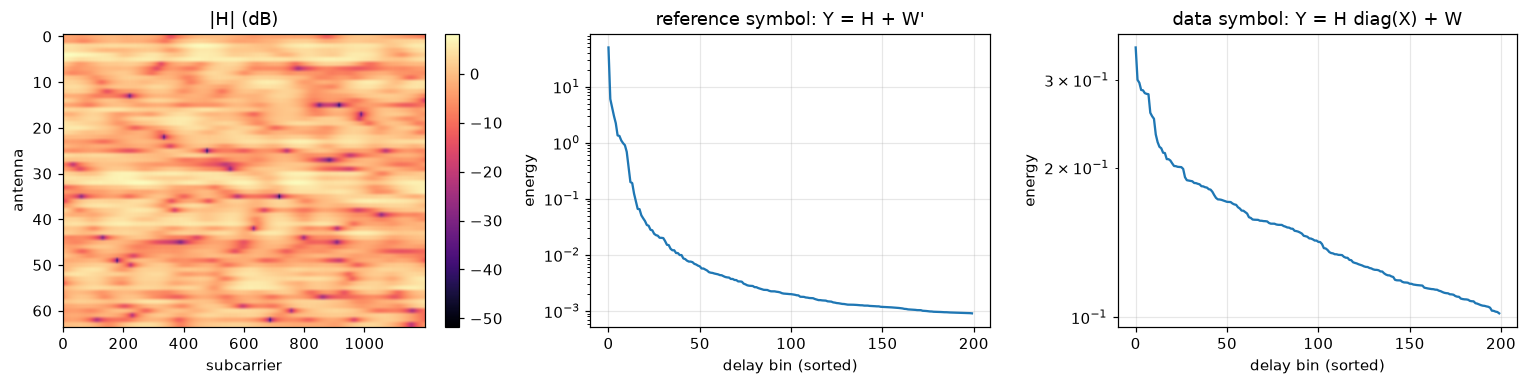

In [2]:
cfg = ChannelConfig(M=64, N=1200, SNR_dB=20.0, seed=42)
channel = TDLAChannel(cfg)
H = channel.generate_H()
Y_ref, S_ref = channel.generate_received_signal(H, return_clean=True, symbol_type="reference")
Y_dat = channel.generate_received_signal(H, symbol_type="data")

print(f"H shape {H.shape}, rank(H) <= 23 taps; numerical rank (99% energy): "
      f"reference {estimate_rank(Y_ref)}, data {estimate_rank(Y_dat)}, fast(1/8 subcarriers) {estimate_rank_fast(Y_ref)}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
im = axes[0].imshow(20*np.log10(np.abs(H)+1e-12), aspect="auto", cmap="magma")
axes[0].set_title("|H| (dB)"); axes[0].set_xlabel("subcarrier"); axes[0].set_ylabel("antenna"); plt.colorbar(im, ax=axes[0], fraction=0.046)
for ax, Y, t in ((axes[1], Y_ref, "reference symbol: Y = H + W'"), (axes[2], Y_dat, "data symbol: Y = H diag(X) + W")):
    p = np.sum(np.abs(np.fft.ifft(Y, axis=1))**2, axis=0)
    ax.semilogy(np.sort(p)[::-1][:200]); ax.set_title(t); ax.set_xlabel("delay bin (sorted)"); ax.set_ylabel("energy"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 3. Single-symbol encoder benchmark (M=64, N=1200, SNR=20 dB)
Compression ratio is relative to 16-bit I/Q components (the eCPRI/O-RAN uncompressed width).
Times are medians of 7 numpy runs on this machine — relative comparison only.

In [3]:
orig_b = original_bits(cfg.M, cfg.N)
def time_ms(fn, reps=7):
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter(); fn(); ts.append((time.perf_counter()-t0)*1000)
    return float(np.median(ts))

rows = []
for sym, Y, S in (("reference", Y_ref, S_ref), ("data", Y_dat, None)):
    enc = bfp_encode(Y, bits=8); Yh = bfp_decode(enc)
    rows.append(dict(symbols=sym, method="O-RAN BFP (b=8)", nmse_Y=nmse(Y, Yh), CR=compression_ratio(orig_b, bfp_bits_used(enc)), ms=time_ms(lambda: bfp_encode(Y, bits=8))))
    for name, e in (("Truncated SVD (r=12,b=10)", SVDEncoder(12, 10)), ("CSEE (K=120,b=10)", CSEEEncoder(120, 10)), ("RAS-BFP (r=12,b=10,SRHT)", RASBFPEncoder(12, 10))):
        enc = e.encode(Y); Yh = e.decode(enc)
        rows.append(dict(symbols=sym, method=name, nmse_Y=nmse(Y, Yh), CR=e.compression_ratio(enc), ms=time_ms(lambda: e.encode(Y))))
df = pd.DataFrame(rows)
df["nmse_Y"] = df["nmse_Y"].map(lambda x: f"{x:.1f} dB"); df["CR"] = df["CR"].map(lambda x: f"{x:.1f}x"); df["ms"] = df["ms"].map(lambda x: f"{x:.2f}")
display(df.pivot(index="method", columns="symbols", values=["nmse_Y", "CR", "ms"]))
print("CSEE Prop.1 prediction at K=120, b=10 (reference):",
      f"{10*np.log10(CSEEEncoder.theoretical_nmse_bound(Y_ref, 120, 10)):.1f} dB (estimate), "
      f"{10*np.log10(CSEEEncoder.theoretical_nmse_bound(Y_ref, 120, 10, worst_case=True)):.1f} dB (worst case)")

nmse_Y               CR               ms  \
symbols                        data reference   data reference   data   
method                                                                  
CSEE (K=120,b=10)           -1.5 dB  -20.3 dB  15.6x     15.6x   0.57   
O-RAN BFP (b=8)            -46.5 dB  -46.5 dB   2.0x      2.0x   0.67   
RAS-BFP (r=12,b=10,SRHT)   -17.6 dB  -17.6 dB   8.0x      8.0x   2.53   
Truncated SVD (r=12,b=10)  -21.5 dB  -21.5 dB   8.0x      8.0x  12.94   

                                     
symbols                   reference  
method                               
CSEE (K=120,b=10)              0.59  
O-RAN BFP (b=8)                0.67  
RAS-BFP (r=12,b=10,SRHT)       2.58  
Truncated SVD (r=12,b=10)     12.00

CSEE Prop.1 prediction at K=120, b=10 (reference): -20.3 dB (estimate), -20.3 dB (worst case)


## 4. ACAFS: rank-adaptive stream / split selection
Bandwidth reference is the fixed antenna-space split (all 64 streams). Split 6 is the *cheapest* option on the
fronthaul (transport blocks) and is only allowed if the RU may run the full uplink PHY.

In [4]:
acafs = ACAFSController(tau_low=0.15, tau_high=0.55, M=64)
demo_ranks = np.array([4, 8, 12, 20, 28, 40, 48, 56])
tbl = pd.DataFrame({"rank r": demo_ranks, "r/M": np.round(demo_ranks/64, 3),
                    "split": [s.value for s in acafs.select_splits_batch(demo_ranks)],
                    "streams tx": [acafs.select_split(int(r))[1] for r in demo_ranks],
                    "saving vs antenna-space": [f"{100*acafs.bw_reduction_for_rank(int(r)):.0f}%" for r in demo_ranks]})
display(tbl)
print(f"Prop. 5 (uniform rank) expected saving: split 6 allowed {100*ACAFSController.theorem5_bound(64,0.15,0.55):.1f}%, "
      f"beam-space only {100*ACAFSController.theorem5_bound(64,0.15,0.55,allow_split6=False):.1f}%")
print(f"This realisation (rank {estimate_rank(Y_ref)}): {acafs.select_split(estimate_rank(Y_ref))}")

,rank r,r/M,split,streams tx,saving vs antenna-space
0,4,0.062,7.2x,10,84%
1,8,0.125,7.2x,10,84%
2,12,0.188,7.2x,12,81%
3,20,0.312,7.2x,20,69%
4,28,0.438,7.2x,28,56%
5,40,0.625,6,40,88%
6,48,0.750,6,48,86%
7,56,0.875,6,56,84%


Prop. 5 (uniform rank) expected saving: split 6 allowed 76.8%, beam-space only 38.1%
This realisation (rank 10): (<FunctionalSplit.SPLIT_72x: '7.2x'>, 10)


## 5. Capacity-constrained allocation across 8 cells (the load-management step)
Eight RUs with SNR {0,...,30,20} dB share one link. Each RU gets one CSEE operating point `(K, bits)` from a menu
of 66. The controller only uses **predicted** distortion (Prop. 1) — then we encode for real and measure.

In [5]:
snrs = [0, 5, 10, 15, 20, 25, 30, 20]
Ys, Ss = [], []
for k, s in enumerate(snrs):
    ch = TDLAChannel(ChannelConfig(M=64, N=1200, SNR_dB=s, seed=100 + k))
    Y, S = ch.generate_received_signal(ch.generate_H(), return_clean=True, symbol_type="reference"); Ys.append(Y); Ss.append(S)
Yb, Sb = np.stack(Ys), np.stack(Ss)
Ks, bits = [24, 40, 60, 90, 120, 200, 300, 450, 600, 900, 1200], [4, 6, 8, 10, 12, 14]
menu = build_csee_menu(Yb, Ks, bits)
menu_clean = build_csee_menu(Yb, Ks, bits, noise_var=[10**(-s/10) for s in snrs])
raw = 2*64*1200*16*len(snrs)
print(f"raw antenna-space load: {bits_per_symbol_to_gbps(raw):.1f} Gbps for {len(snrs)} cells; menu prediction took {menu.prediction_time_s*1e3:.0f} ms")

def measured(menu_, res):
    vy, vc = [], []
    for c in range(len(snrs)):
        if res.dropped[c]: vy.append(0.0); vc.append(0.0); continue
        p = menu_.params[res.choice[c]]; e = CSEEEncoder(p["K"], p["bits"]); Yh = e.decode(e.encode(Yb[c]))
        vy.append(nmse(Yb[c], Yh)); vc.append(nmse(Sb[c], Yh))
    return np.array(vy), np.array(vc)

out = []
for frac in (0.2, 0.05, 0.02):
    C = raw*frac
    for name, m, res in (("uniform-CSEE", menu, uniform_allocate(menu.rates, menu.predicted, C)),
                         ("greedy-sum", menu, greedy_allocate(menu.rates, menu.predicted, C)),
                         ("greedy-clean (noise-aware)", menu_clean, greedy_allocate(menu_clean.rates, menu_clean.predicted, C))):
        vy, vc = measured(m, res)
        out.append(dict(capacity=f"{bits_per_symbol_to_gbps(C):.1f} Gbps ({frac:g} raw)", policy=name,
                        util=f"{100*res.utilization:.0f}%", **{"avg NMSE vs Y": f"{vy.mean():.1f} dB", "avg NMSE vs H": f"{vc.mean():.1f} dB"},
                        alloc_ms=f"{res.decision_time_s*1e3:.2f}", choices=" | ".join(f"K{m.params[i]['K']}b{m.params[i]['bits']}" if i >= 0 else "DROP" for i in res.choice)))
display(pd.DataFrame(out))

raw antenna-space load: 275.3 Gbps for 8 cells; menu prediction took 26 ms


,capacity,policy,util,avg NMSE vs Y,avg NMSE vs H,alloc_ms,choices
0,55.1 Gbps (0.2 raw),uniform-CSEE,98%,-17.1 dB,-15.9 dB,0.10,K600b6 | K600b6 | K600b6 | K600b6 | K600b6 | K...
1,55.1 Gbps (0.2 raw),greedy-sum,98%,-23.0 dB,-16.4 dB,0.86,K1200b6 | K1200b6 | K1200b6 | K600b6 | K120b8 ...
2,55.1 Gbps (0.2 raw),greedy-clean (noise-aware),84%,-16.6 dB,-22.9 dB,0.81,K24b14 | K40b14 | K60b14 | K90b14 | K200b14 | ...
3,13.8 Gbps (0.05 raw),uniform-CSEE,78%,-14.4 dB,-19.0 dB,0.07,K120b6 | K120b6 | K120b6 | K120b6 | K120b6 | K...
4,13.8 Gbps (0.05 raw),greedy-sum,99%,-15.2 dB,-17.5 dB,0.60,K1200b4 | K90b6 | K60b6 | K40b8 | K40b8 | K40b...
5,13.8 Gbps (0.05 raw),greedy-clean (noise-aware),100%,-15.3 dB,-22.4 dB,0.63,K24b12 | K40b12 | K60b10 | K60b12 | K120b10 | ...
6,5.5 Gbps (0.02 raw),uniform-CSEE,98%,-13.7 dB,-19.2 dB,0.06,K60b6 | K60b6 | K60b6 | K60b6 | K60b6 | K60b6 ...
7,5.5 Gbps (0.02 raw),greedy-sum,100%,-12.8 dB,-16.3 dB,0.47,K450b4 | K40b6 | K24b6 | K24b6 | K24b6 | K24b6...
8,5.5 Gbps (0.02 raw),greedy-clean (noise-aware),99%,-14.1 dB,-20.8 dB,0.46,K24b8 | K24b8 | K40b8 | K40b8 | K60b8 | K60b8 ...


## 6. Experiment figures (regenerated by `experiments/exp*.py`)

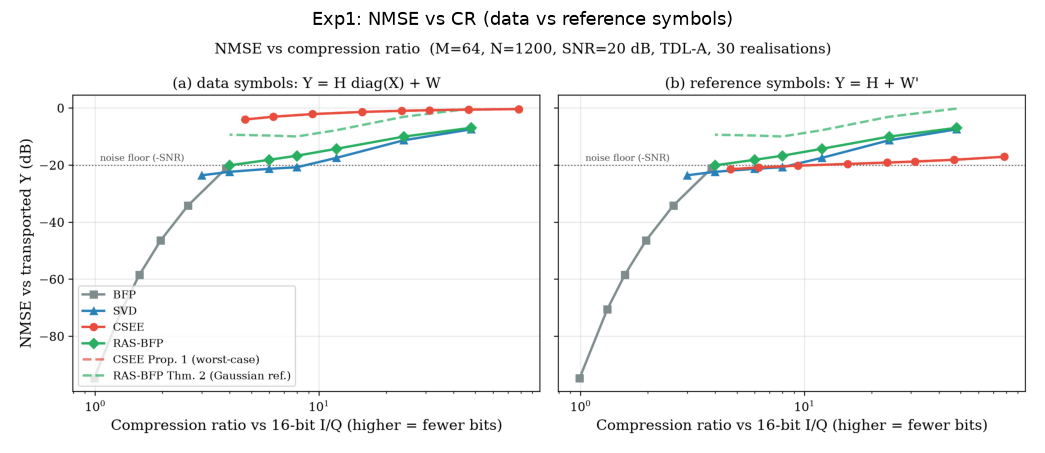

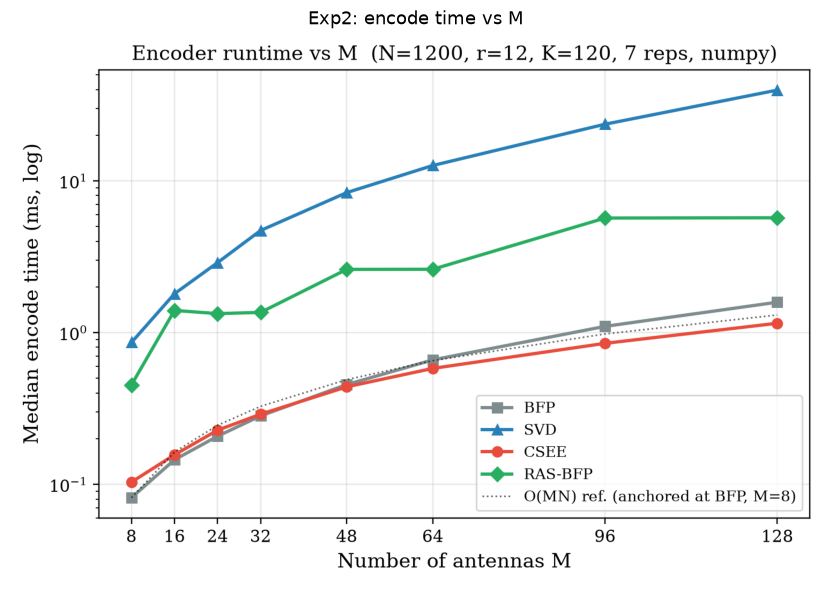

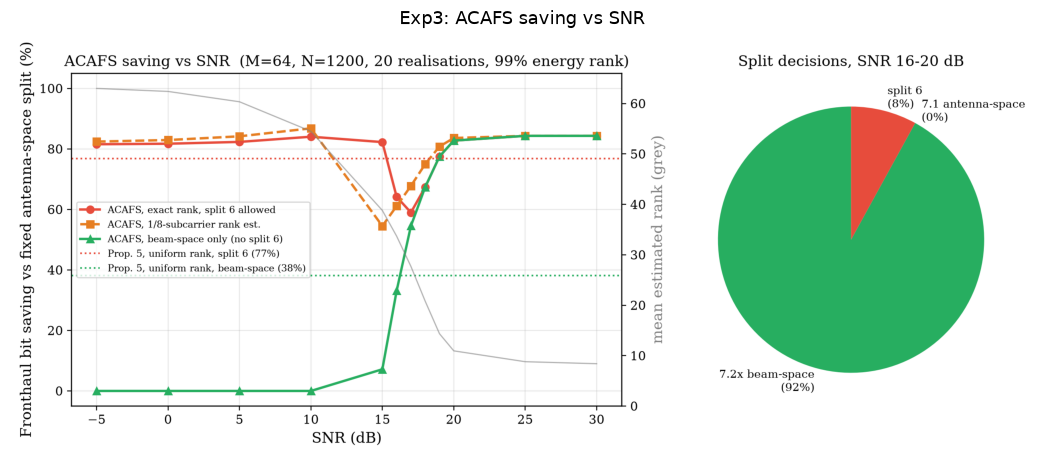

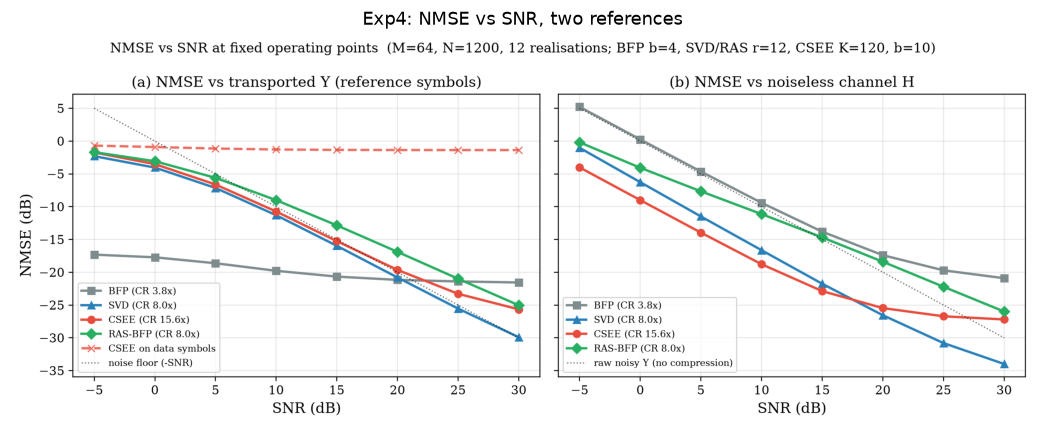

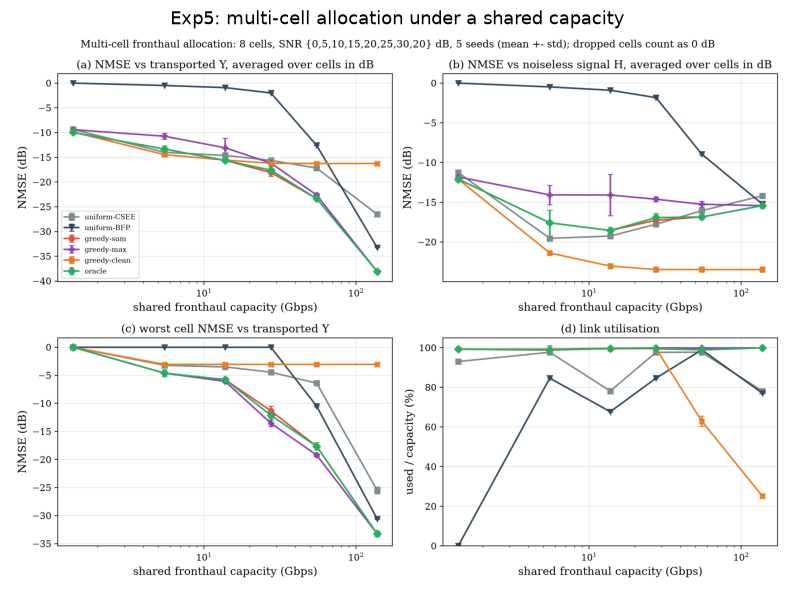

In [6]:
fig_dir = os.path.join("..", "results", "figures")
files = [("exp1_nmse_vs_cr.png", "Exp1: NMSE vs CR (data vs reference symbols)"), ("exp2_complexity.png", "Exp2: encode time vs M"),
         ("exp3_acafs.png", "Exp3: ACAFS saving vs SNR"), ("exp4_snr_sweep.png", "Exp4: NMSE vs SNR, two references"),
         ("exp5_allocation.png", "Exp5: multi-cell allocation under a shared capacity")]
for fname, title in files:
    path = os.path.join(fig_dir, fname)
    if os.path.exists(path):
        plt.figure(figsize=(12, 6.5)); plt.imshow(plt.imread(path)); plt.axis("off"); plt.title(title); plt.show()
    else:
        print("missing:", fname)